In [1]:
#%pip install flavio wilson iminuit matplotlib numpy scipy

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from iminuit import Minuit
import flavio
from flavio.statistics.likelihood import FastLikelihood

observables = [
    # Muy limpios y centrales
    'BR(Bs->mumu)',
    'BR(B0->mumu)',  # para evitar inconsistencia: algunas measurements constriñen ambos a la vez

    # LFU ratios (R_K y R_K* en bins típicos)
    ('<Rmue>(B+->Kll)', 1.1, 6.0),         # ~ R_K
    ('<Rmue>(B0->K*ll)', 0.045, 1.1),      # ~ R_K* low-q2
    ('<Rmue>(B0->K*ll)', 1.1, 6.0),        # ~ R_K* central-q2

    # Angular observable (P5') en región q2 donde QCDF es "más razonable"
    ('<P5p>(B0->K*mumu)', 4.0, 6.0),

    # Differential BR examples (en región baja q2)
    ('<dBR/dq2>(B+->Kmumu)', 1.1, 6.0),
    ('<dBR/dq2>(Bs->phimumu)', 1.1, 6.0),
]

In [3]:
# Centramos los parámetros del SM para el cálculo de la log-likelihood
par_central = flavio.default_parameters.get_central_all()

# Usamos FastLikelihood para crear la función de log-verosimilitud con los observables y parámetros definidos
fl = FastLikelihood('rareB_baseline', observables=observables, nuisance_parameters='all')

# Hacemos un test rápido para asegurarnos de que todo funciona y no hay errores de configuración
fl.make_measurement(N=3000, Nexp=3000, threads=1)

# Log-likelihood en el SM (WCs NP = 0)
wc_sm = flavio.WilsonCoefficients()    # SM => NP contribuciones = 0
ll_sm = fl.log_likelihood(par_central, wc_sm)
ll_sm

np.float64(55.389855488125065)

In [4]:
# Modificamos la función para que solo reciba y varíe C9
def loglike_C9(C9, scale=5.0):
    wc = flavio.WilsonCoefficients()
    wc.set_initial({'C9_bsmumu': C9}, scale)
    return fl.log_likelihood(par_central, wc)

def nll(C9):
    return -loglike_C9(C9)

# Inicializamos Minuit con un solo parámetro
m = Minuit(nll, C9=0.0)
m.errordef = 0.5  # NLL = -logL

# 1) Minimización
m.migrad()

# 2) Errores (Hesse) y (opcional) Minos
m.hesse()
m.minos() 

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = -72.5                      │              Nfcn = 28               │
│ EDM = 1.91e-07 (Goal: 0.0001)    │           time = 14.6 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ C9   │   -0.65   │   0.12    │   -0.13    │    0.12    │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┐
│          │          C9           │
├──────────┼───────────┬───────────┤
│  Error   │   -0.13   │   0.12    │
│  Valid   │   True    │   True    │
│ At Limit │   False   │   False   │
│ Max FCN  │   False   │   False   │
│ New Min  │   False   │   False   │
└──────────┴───────────┴───────────┘
┌────┬────────┐
│    │     C9 │
├────┼────────┤
│ C9 │ 0.0151 │
└────┴────────┘

In [5]:
print("\n=== Best-fit parameter ===")
for p in m.params:
    print(f"{p.name:6s} = {p.value:+.6f} ± {p.error:.6f}")

print("\n=== MINOS errors ===")
for n in m.parameters:
    me = m.merrors[n]
    print(f"{n:6s}: {me.lower:+.6f}  {me.upper:+.6f}")


=== Best-fit parameter ===
C9     = -0.653059 ± 0.122799

=== MINOS errors ===
C9    : -0.125213  +0.120540



=== SM Pull (Exacto) ===
Delta chi^2: 34.22
Grados de libertad (DOF): 1
p-value del SM: 4.92e-09
Pull del SM: 5.85 sigmas


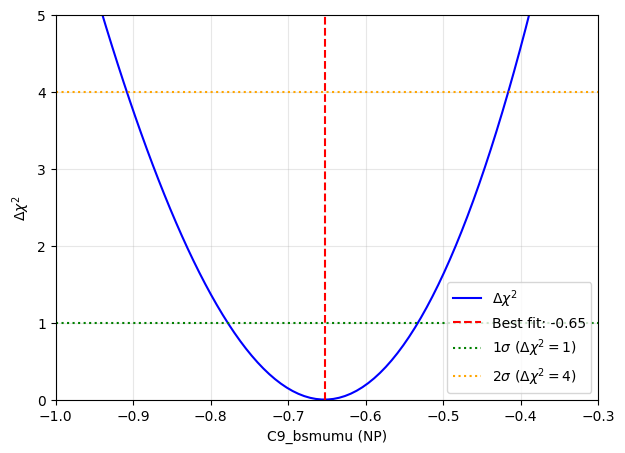

In [6]:
# Extraemos el best-fit y el máximo likelihood
C9_best = m.values['C9']
ll_max = -m.fval

delta_chi2_sm = -2 * (ll_sm - ll_max)

# Definimos los grados de libertad
gl = 1  

# 1. Obtenemos el p-value desde la distribución chi-cuadrado (survival function)
p_value = stats.chi2.sf(delta_chi2_sm, df=gl)

# 2. Convertimos el p-value a sigmas (Z) usando la normal estándar inversa.
# Se divide el p-value entre 2 por convención (probabilidad de dos colas simétricas)
pull_sm = stats.norm.isf(p_value / 2)

print("\n=== SM Pull (Exacto) ===")
print(f"Delta chi^2: {delta_chi2_sm:.2f}")
print(f"Grados de libertad (DOF): {gl}")
print(f"p-value del SM: {p_value:.2e}")
print(f"Pull del SM: {pull_sm:.2f} sigmas")

# Grid 1D alrededor del best-fit
C9_grid = np.linspace(C9_best - 1.5, C9_best + 1.5, 400)
delta_chi2 = np.zeros_like(C9_grid)

# Escaneamos los valores
for i, C9 in enumerate(C9_grid):
    ll = loglike_C9(C9)
    delta_chi2[i] = -2 * (ll - ll_max)

# Graficamos la parábola de Delta chi^2
plt.figure(figsize=(7, 5))
plt.plot(C9_grid, delta_chi2, label=r'$\Delta\chi^2$', color='blue')

# Marcamos el best-fit
plt.axvline(C9_best, color='red', linestyle='--', label=f'Best fit: {C9_best:.2f}')

# Líneas horizontales para 1 sigma y 2 sigma (1 DOF)
plt.axhline(1.0, color='green', linestyle=':', label=r'$1\sigma \ (\Delta\chi^2=1)$')
plt.axhline(4.0, color='orange', linestyle=':', label=r'$2\sigma \ (\Delta\chi^2=4)$')

plt.xlabel('C9_bsmumu (NP)')
plt.ylabel(r'$\Delta\chi^2$')
#plt.title(r'Escaneo 1D de FastLikelihood para $C_9^\mu $')
plt.ylim(0, 5)
plt.xlim(-1, -0.3)
plt.legend()
plt.grid(alpha=0.3)
plt.show()